In [10]:
%load_ext autoreload
%autoreload 2

import pyttb as ttb
import numpy as np

# add common to python path
import os
import sys

import goated.utils.exo as ex
import goated.utils.scalers as sc
import goated.goals.physics as goals

import goated.rol_interface.models as rolm
import goated.rol_interface.objective as rolo
from goated.cp import GocchaObjective, CPGoal
import goated.utils.vectorization as uvec

# add ROL things
import copy
from pyrol import getCout, ParameterList, Problem, Solver


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
# Exodus file name with tensor data
# fname = '/Volumes/phited/DrekarData/TearingMode/john_2024_08_29/output_2D_TearingMode_64x32_S_1E3.exo'
# fname = '/Users/rjmurr/Documents/ascend/combined-cp-tucker-opt/data/1E3_2D_TearingMode.exo'
fname = '/Users/rjmurr/Documents/ascend/combined-cp-tucker-opt/data/output_2D_TearingMode_64x32_S_1E3.exo'


do_goal_plots = True  # construct goal plots
save_data = False     # save tensor reconstructions to disk
save_figs = False     # save figures
rank = 15             # Rank of the CP decomposition
maxiters = 30         # max iterations of gcp_opt
pgtol = 1e-2          # BFGS tolerance

In [12]:
# Read tensor from exodus file
exo = ex.ExoInfo()
exo.read_sheet(fname)
time = exo.t
num_time = len(time)

In [13]:
# Some global parameters
vars = [0,1,3,4,6,7,9]       # Exclude BZ, R, RHO_UZ, and U
B_var_ind = [0,1]            # variable indices for magnetic field
rho_var_ind = [2]            # variable index for density
mom_var_ind = [4,5]          # variables for momentum goal
T_var_ind = [6]              # variable index for temperature
tot_var_ind = B_var_ind+rho_var_ind+mom_var_ind+T_var_ind
int_var_ind = rho_var_ind+T_var_ind
kin_var_ind = rho_var_ind+mom_var_ind
mom_time_ind = range(1,num_time)    # time steps for momenum goal (exclude first few)
energy_time_ind = range(0,num_time) # time steps for energy goals

# select subset of variables
X = ttb.tensor(exo.tensor_data[:,:,vars,:])
sz = X.shape
var_labels = [exo.var_name[v] for v in vars]

In [14]:
# scale tensor values so that each variable has roughly the same order of magnitude
scaler = sc.StdScaler(X,exo.var_mode)
Xs = scaler.scale_tensor(X)
us0,_,_ = ttb.cp_als(Xs,rank=rank,maxiters=50)
U0 = scaler.unscale_tensor(us0.full())
fit0 = 1-(X-U0).norm()/X.norm()

CP_ALS:
 Iter 0: f = 5.551428e-01 f-delta = 5.6e-01
 Iter 1: f = 7.649276e-01 f-delta = 2.1e-01
 Iter 2: f = 8.294879e-01 f-delta = 6.5e-02
 Iter 3: f = 8.459863e-01 f-delta = 1.6e-02
 Iter 4: f = 8.569205e-01 f-delta = 1.1e-02
 Iter 5: f = 8.663530e-01 f-delta = 9.4e-03
 Iter 6: f = 8.756387e-01 f-delta = 9.3e-03
 Iter 7: f = 8.847144e-01 f-delta = 9.1e-03
 Iter 8: f = 8.909168e-01 f-delta = 6.2e-03
 Iter 9: f = 8.956226e-01 f-delta = 4.7e-03
 Iter 10: f = 8.999948e-01 f-delta = 4.4e-03
 Iter 11: f = 9.034855e-01 f-delta = 3.5e-03
 Iter 12: f = 9.062143e-01 f-delta = 2.7e-03
 Iter 13: f = 9.084393e-01 f-delta = 2.2e-03
 Iter 14: f = 9.103130e-01 f-delta = 1.9e-03
 Iter 15: f = 9.119267e-01 f-delta = 1.6e-03
 Iter 16: f = 9.133509e-01 f-delta = 1.4e-03
 Iter 17: f = 9.146275e-01 f-delta = 1.3e-03
 Iter 18: f = 9.157780e-01 f-delta = 1.2e-03
 Iter 19: f = 9.168139e-01 f-delta = 1.0e-03
 Iter 20: f = 9.177426e-01 f-delta = 9.3e-04
 Iter 21: f = 9.185705e-01 f-delta = 8.3e-04
 Iter 22: f 

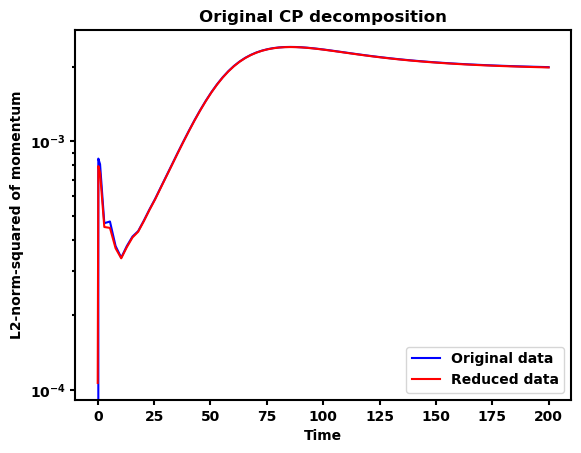

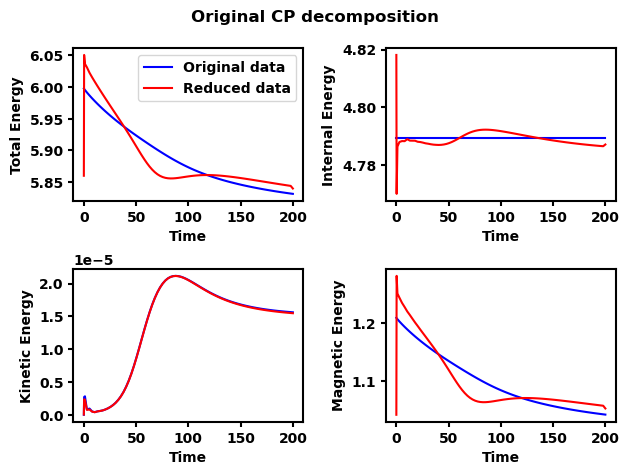

In [15]:
if do_goal_plots:
    fig,ax = goals.plot_momentum(X,us0,mom_var_ind,None,time,exo,scaler)
    ax.set_title('Original CP decomposition', fontweight='bold')
    if save_figs:
        fig.savefig('mom-initial.png')

    fig,axs = goals.plot_energies(X,us0,rho_var_ind,T_var_ind,mom_var_ind,B_var_ind,None,time,exo,scaler)
    fig.suptitle('Original CP decomposition', fontweight='bold')
    if save_figs:
        fig.savefig('energy-initial.png')

In [16]:
mom_goal = goals.MomentumGoal(X,mom_var_ind,mom_time_ind,exo)
E_goal = goals.TotalEnergyGoal(X,tot_var_ind,energy_time_ind,exo)
T_goal = goals.InternalEnergyGoal(X,int_var_ind,energy_time_ind,exo)
P_goal = goals.KineticEnergyGoal(X,kin_var_ind,energy_time_ind,exo)
B_goal = goals.MagneticEnergyGoal(X,B_var_ind,energy_time_ind,exo)

mom_goal0 = mom_goal.computeValue(U0)
E_goal0 = E_goal.computeValue(U0)
T_goal0 = T_goal.computeValue(U0)
P_goal0 = P_goal.computeValue(U0)
B_goal0 = B_goal.computeValue(U0)

print(f'Initial fit = {fit0:.4f}, momentum goal = {mom_goal0:.2e}, total energy goal = {E_goal0:.2e}, internal energy goal = {T_goal0:.2e}, kinetic energy goal {P_goal0:.2e}, magnetic energy goal = {B_goal0:.2e}')

Initial fit = 0.9980, momentum goal = 9.43e-09, total energy goal = 5.47e-02, internal energy goal = 1.48e-03, kinetic energy goal 8.25e-13, magnetic energy goal = 7.01e-02


In [17]:
my_goals = [mom_goal,T_goal,P_goal,B_goal]
ng = len(my_goals)+1
weights = [1/(ng*mom_goal0),1/(ng*T_goal0),1/(ng*P_goal0),1/(ng*B_goal0)]
goal = CPGoal(scaler, my_goals, weights)
a = 1/(ng*((Xs-us0.full()).norm()**2))
cp = GocchaObjective(Xs, goal, a, 1.0)
_ = us0.normalize(weight_factor='all')

In [19]:
precondition = True

stream = getCout()

x = uvec.ktensor_to_rolvec(us0)
# x = CPVector(copy.deepcopy(us0.factor_matrices))
g = x.dual()

objective = rolo.GocchaRolObjective(precondition, cp)
problem = Problem(objective, x, g)
#problem.check(True, stream)

params = rolm.build_cp_parameter_list()
solver = Solver(problem, params)
solver.solve(stream)


Truncated CG Trust-Region Solver
  iter  value          gnorm          snorm          delta          #fval     #grad     tr_flag   iterCG    flagCG    
  0     1.000000e+00   4.049181e+01   ---            6.914203e-03   2         1         ---       ---       ---       
  1     9.974135e-01   4.016478e+01   6.914203e-03   1.728551e-02   3         2         0         1         3         
  2     9.910280e-01   3.935080e+01   1.728551e-02   4.321377e-02   4         3         0         1         3         
  3     9.755642e-01   3.733926e+01   4.321377e-02   1.080344e-01   5         4         0         1         3         
  4     9.399500e-01   3.247676e+01   1.080344e-01   2.700860e-01   6         5         0         1         3         
  5     8.684653e-01   2.180997e+01   2.700860e-01   6.752151e-01   7         6         0         1         3         
  6     7.649420e-01   1.506788e+01   6.752151e-01   1.688038e+00   8         7         0         1         3         
  7     5.9779

0

In [11]:
us1 = ttb.ktensor(x.data)
U1 = scaler.unscale_tensor(us1.full())
fit1 = 1-(X-U1).norm()/X.norm()
mom_goal1 = mom_goal.computeValue(U1)
E_goal1 = E_goal.computeValue(U1)
T_goal1 = T_goal.computeValue(U1)
P_goal1 = P_goal.computeValue(U1)
B_goal1 = B_goal.computeValue(U1)

print(f'Final fit = {fit1:.4f}, momentum goal = {mom_goal1:.2e}, total energy goal = {E_goal1:.2e}, internal energy goal = {T_goal1:.2e}, kinetic energy goal {P_goal1:.2e}, magnetic energy goal = {B_goal1:.2e}')

Final fit = 0.9975, momentum goal = 2.32e-10, total energy goal = 5.30e-07, internal energy goal = 8.26e-08, kinetic energy goal 7.15e-15, magnetic energy goal = 5.68e-07


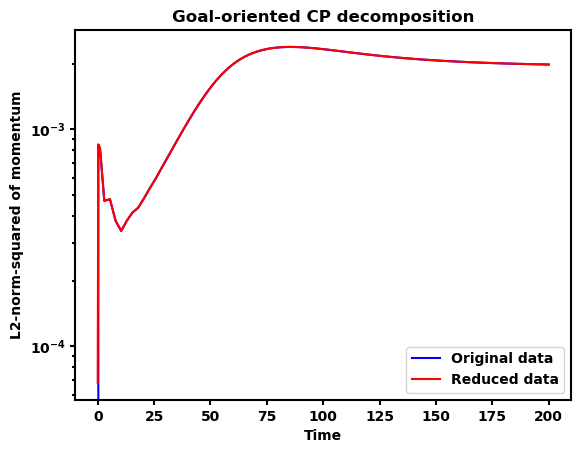

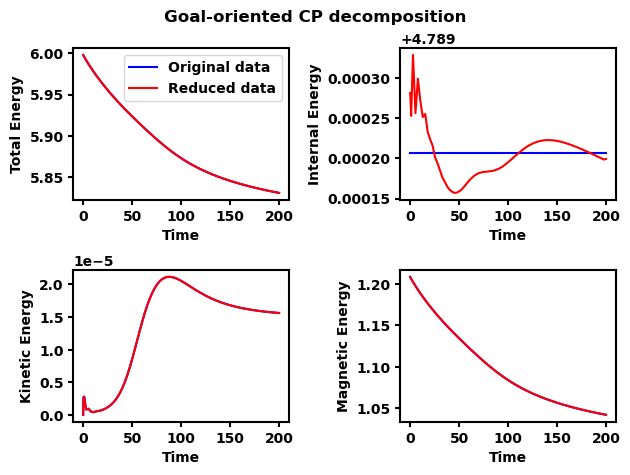

In [12]:
if do_goal_plots:
    fig,ax = goals.plot_momentum(X,us1,mom_var_ind,None,time,exo,scaler)
    ax.set_title('Goal-oriented CP decomposition',fontweight='bold')
    if save_figs:
        fig.savefig('mom-final.png')

    fig,axs = goals.plot_energies(X,us1,rho_var_ind,T_var_ind,mom_var_ind,B_var_ind,None,time,exo,scaler)
    fig.suptitle('Goal-oriented CP decomposition',fontweight='bold')
    if save_figs:
        fig.savefig('energy-final.png')